# Groupe 3 — Approche 2 : Random Forest

**Sujet :** Gestion intelligente du trafic routier sur la réduction des embouteillages en temps réel.

Ce notebook utilise exactement le même fichier `dataset_trafic_ml.csv` issu de NetLogo/BehaviorSpace.

Objectif : prédire le **niveau de congestion 20 ticks dans le futur** (`FAIBLE`, `MOYENNE`, `FORTE`) avec une approche différente de CatBoost.

Méthode :
- 70 % train
- 15 % validation
- 15 % test
- séparation par **run complet**
- sélection du meilleur Random Forest sur la validation avec **F1 macro**
- évaluation finale unique sur le test

## 1. Imports

In [1]:
from pathlib import Path
import json
import re
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

warnings.filterwarnings("ignore")

RANDOM_SEED = 42
HORIZON = 20

print("Approche : Random Forest")
print("Horizon :", HORIZON, "ticks")

Approche : Random Forest
Horizon : 20 ticks


## 2. Trouver automatiquement le dataset

In [2]:
def trouver_dataset():
    candidats = [
        Path("dataset_trafic_ml.csv"),
        Path("../dataset_trafic_ml.csv"),
        Path("../../dataset_trafic_ml.csv"),
    ]
    for p in candidats:
        if p.exists():
            return p.resolve()

    racine = Path.cwd()
    trouves = list(racine.glob("**/dataset_trafic_ml.csv"))
    if trouves:
        return trouves[0].resolve()

    parent = racine.parent
    trouves = list(parent.glob("**/dataset_trafic_ml.csv"))
    if trouves:
        return trouves[0].resolve()

    raise FileNotFoundError(
        "dataset_trafic_ml.csv introuvable. "
        "Place le CSV dans le dossier du notebook ou dans son dossier parent."
    )

CSV_PATH = trouver_dataset()
print("Dataset :", CSV_PATH)

Dataset : C:\Master_1_projets\TP_NETLOGO_GROUPE3_FINAL_CORRIGE\dataset_trafic_ml.csv


## 3. Lire correctement l'export BehaviorSpace

In [3]:
with open(CSV_PATH, "r", encoding="utf-8-sig", errors="replace") as f:
    lignes = f.readlines()

header_index = None
for i, ligne in enumerate(lignes):
    if "[run number]" in ligne and "[step]" in ligne:
        header_index = i
        break

if header_index is None:
    header_index = 0

df = pd.read_csv(CSV_PATH, skiprows=header_index)
df = df.dropna(axis=1, how="all")

print("Dimensions brutes :", df.shape)
display(df.head())

Dimensions brutes : (168240, 34)


,[run number],control-mode,arrival-rate,ns-demand-share,initial-cars,max-cars,max-speed,fixed-green,min-green,max-green,...,average-speed-value,avg-wait-current-value,total-completed,throughput-value,congestion-index-value,congestion-level,junction-phase-code 1,junction-phase-code 2,junction-phase-code 3,junction-phase-code 4
0,3,CLASSIQUE,20,30,30,300,0.25,60,30,100,...,0.00,0.0,0,0,0.0,FAIBLE,0,1,1,0
1,3,CLASSIQUE,20,30,30,300,0.25,60,30,100,...,0.25,0.0,0,0,0.0,FAIBLE,0,1,1,0
2,3,CLASSIQUE,20,30,30,300,0.25,60,30,100,...,0.25,0.0,0,0,0.0,FAIBLE,0,1,1,0
3,3,CLASSIQUE,20,30,30,300,0.25,60,30,100,...,0.25,0.0,0,0,0.0,FAIBLE,0,1,1,0
4,3,CLASSIQUE,20,30,30,300,0.25,60,30,100,...,0.25,0.0,0,0,0.0,FAIBLE,0,1,1,0


## 4. Nettoyer les noms de colonnes

In [4]:
def nettoyer_nom(col):
    col = str(col).strip()
    col = col.replace("[", "").replace("]", "")
    col = col.replace("?", "")
    col = col.replace("-", "_")
    col = col.replace(" ", "_")
    col = col.replace("/", "_")
    col = col.lower()
    col = re.sub(r"[^a-z0-9_]+", "_", col)
    col = re.sub(r"_+", "_", col)
    return col.strip("_")

df.columns = [nettoyer_nom(c) for c in df.columns]

print("Colonnes :")
for c in df.columns:
    print(" -", c)

Colonnes :
 - run_number
 - control_mode
 - arrival_rate
 - ns_demand_share
 - initial_cars
 - max_cars
 - max_speed
 - fixed_green
 - min_green
 - max_green
 - sensor_range
 - switch_threshold
 - clearance_time
 - slow_visualization
 - visual_delay
 - csv_export
 - export_interval
 - step
 - ticks
 - count_cars
 - stopped_cars_value
 - queue_ns_value
 - queue_ew_value
 - mean_queue_value
 - average_speed_value
 - avg_wait_current_value
 - total_completed
 - throughput_value
 - congestion_index_value
 - congestion_level
 - junction_phase_code_1
 - junction_phase_code_2
 - junction_phase_code_3
 - junction_phase_code_4


## 5. Identifier les colonnes essentielles

In [5]:
def trouver_colonne(possibles, contient=None):
    for p in possibles:
        if p in df.columns:
            return p
    if contient:
        for c in df.columns:
            if all(mot in c for mot in contient):
                return c
    return None

run_col = trouver_colonne(["run_number", "run"], contient=["run"])
step_col = trouver_colonne(["step", "ticks", "tick"], contient=["step"])

congestion_col = trouver_colonne(
    ["congestion_index_value", "congestion_index", "congestion_rate", "indice_congestion", "congestion"],
    contient=["congestion", "index"]
)

niveau_col = trouver_colonne(
    ["congestion_level_value", "congestion_level", "niveau_congestion"],
    contient=["congestion", "level"]
)

print("Run :", run_col)
print("Ticks :", step_col)
print("Indice congestion :", congestion_col)
print("Niveau congestion :", niveau_col)

if run_col is None or step_col is None:
    raise ValueError("Colonnes run/tick introuvables.")
if congestion_col is None and niveau_col is None:
    raise ValueError("Aucune colonne de congestion reconnue.")

Run : run_number
Ticks : step
Indice congestion : congestion_index_value
Niveau congestion : congestion_level


## 6. Créer la cible future à +20 ticks

In [6]:
df[run_col] = pd.to_numeric(df[run_col], errors="coerce")
df[step_col] = pd.to_numeric(df[step_col], errors="coerce")

df = df.dropna(subset=[run_col, step_col]).copy()
df = df.sort_values([run_col, step_col]).reset_index(drop=True)

if niveau_col is not None:
    df["_niveau_normalise"] = (
        df[niveau_col]
        .astype(str)
        .str.upper()
        .str.strip()
        .replace({
            "LOW": "FAIBLE",
            "MEDIUM": "MOYENNE",
            "HIGH": "FORTE",
            "MOYEN": "MOYENNE"
        })
    )
    df["congestion_future"] = (
        df.groupby(run_col)["_niveau_normalise"].shift(-HORIZON)
    )
else:
    df["_congestion_num"] = pd.to_numeric(df[congestion_col], errors="coerce")
    future_index = df.groupby(run_col)["_congestion_num"].shift(-HORIZON)
    df["congestion_future"] = pd.cut(
        future_index,
        bins=[-np.inf, 30, 60, np.inf],
        labels=["FAIBLE", "MOYENNE", "FORTE"]
    ).astype("object")

df = df.dropna(subset=["congestion_future"]).copy()
df["congestion_future"] = (
    df["congestion_future"].astype(str).str.upper().str.strip()
)

print(df["congestion_future"].value_counts())

FAIBLE     135489
MOYENNE     26424
FORTE        1527
Name: congestion_future, dtype: int64


## 7. Ajouter les mêmes informations temporelles que pour l'approche CatBoost

On ajoute des différences à 5 ticks et des moyennes glissantes sur 5 ticks.

In [7]:
colonnes_interdites = {
    run_col, step_col, "congestion_future", "_niveau_normalise", "_congestion_num"
}

for c in df.columns:
    if c not in colonnes_interdites:
        converted = pd.to_numeric(df[c], errors="coerce")
        if converted.notna().mean() > 0.90:
            df[c] = converted

mots_tendance = [
    "queue", "file", "stopped", "arrete", "waiting", "attente",
    "speed", "vitesse", "throughput", "debit", "congestion", "count_cars",
    "nb_vehicules", "vehicles"
]

trend_cols = []
for c in df.columns:
    if c in colonnes_interdites:
        continue
    if pd.api.types.is_numeric_dtype(df[c]) and any(m in c for m in mots_tendance):
        trend_cols.append(c)

trend_cols = trend_cols[:12]

for c in trend_cols:
    df[f"{c}_delta5"] = df.groupby(run_col)[c].diff(5)
    df[f"{c}_moy5"] = (
        df.groupby(run_col)[c]
          .rolling(5, min_periods=1)
          .mean()
          .reset_index(level=0, drop=True)
    )

print("Variables temporelles ajoutées :", trend_cols)

Variables temporelles ajoutées : ['max_speed', 'count_cars', 'stopped_cars_value', 'queue_ns_value', 'queue_ew_value', 'mean_queue_value', 'average_speed_value', 'throughput_value', 'congestion_index_value']


## 8. Construire les variables explicatives

In [8]:
exclure = {
    run_col,
    step_col,
    "congestion_future",
    "_niveau_normalise",
    "_congestion_num"
}

for c in df.columns:
    if c.startswith("run_number") or c.startswith("step"):
        exclure.add(c)

features = [c for c in df.columns if c not in exclure]

features_valides = []
for c in features:
    if df[c].notna().sum() == 0:
        continue
    if df[c].nunique(dropna=True) <= 1:
        continue
    features_valides.append(c)

features = features_valides

X = df[features].copy()
y = df["congestion_future"].copy()
groups = df[run_col].astype(int).copy()

print("Nombre de variables :", len(features))
print("X :", X.shape)

Nombre de variables : 35
X : (163440, 35)


## 9. Train / Validation / Test par run

In [9]:
split1 = GroupShuffleSplit(
    n_splits=1,
    train_size=0.70,
    random_state=RANDOM_SEED
)
train_idx, temp_idx = next(split1.split(X, y, groups=groups))

X_train = X.iloc[train_idx].copy()
y_train = y.iloc[train_idx].copy()
g_train = groups.iloc[train_idx].copy()

X_temp = X.iloc[temp_idx].copy()
y_temp = y.iloc[temp_idx].copy()
g_temp = groups.iloc[temp_idx].copy()

split2 = GroupShuffleSplit(
    n_splits=1,
    train_size=0.50,
    random_state=RANDOM_SEED
)
val_rel_idx, test_rel_idx = next(split2.split(X_temp, y_temp, groups=g_temp))

X_val = X_temp.iloc[val_rel_idx].copy()
y_val = y_temp.iloc[val_rel_idx].copy()
g_val = g_temp.iloc[val_rel_idx].copy()

X_test = X_temp.iloc[test_rel_idx].copy()
y_test = y_temp.iloc[test_rel_idx].copy()
g_test = g_temp.iloc[test_rel_idx].copy()

print("TRAIN :", X_train.shape, "| runs :", g_train.nunique())
print("VALID :", X_val.shape, "| runs :", g_val.nunique())
print("TEST  :", X_test.shape, "| runs :", g_test.nunique())

print("Train ∩ Validation :", len(set(g_train) & set(g_val)))
print("Train ∩ Test       :", len(set(g_train) & set(g_test)))
print("Validation ∩ Test  :", len(set(g_val) & set(g_test)))

TRAIN : (114408, 35) | runs : 168
VALID : (24516, 35) | runs : 36
TEST  : (24516, 35) | runs : 36
Train ∩ Validation : 0
Train ∩ Test       : 0
Validation ∩ Test  : 0


## 10. Prétraitement

Random Forest n'accepte pas directement les colonnes texte.
On encode donc les variables catégorielles, et on impute les valeurs manquantes.

In [10]:
categorical_cols = [
    c for c in X_train.columns
    if X_train[c].dtype == "object"
]

numeric_cols = [
    c for c in X_train.columns
    if c not in categorical_cols
]

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(
        handle_unknown="use_encoded_value",
        unknown_value=-1
    ))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_cols),
    ("cat", categorical_transformer, categorical_cols)
])

print("Numériques :", len(numeric_cols))
print("Catégorielles :", categorical_cols)

Numériques : 33
Catégorielles : ['control_mode', 'congestion_level']


## 11. Sélection du meilleur Random Forest sur la validation

On teste plusieurs configurations raisonnables.
Le jeu TEST reste totalement intact pendant cette sélection.

In [11]:
configs = [
    {
        "n_estimators": 300,
        "max_depth": 12,
        "min_samples_leaf": 2,
        "max_features": "sqrt"
    },
    {
        "n_estimators": 500,
        "max_depth": 16,
        "min_samples_leaf": 2,
        "max_features": "sqrt"
    },
    {
        "n_estimators": 500,
        "max_depth": None,
        "min_samples_leaf": 3,
        "max_features": "sqrt"
    },
    {
        "n_estimators": 700,
        "max_depth": 18,
        "min_samples_leaf": 3,
        "max_features": 0.7
    }
]

essais = []
best_model = None
best_f1 = -1
best_config = None

for i, cfg in enumerate(configs, start=1):
    rf = RandomForestClassifier(
        **cfg,
        class_weight="balanced_subsample",
        random_state=RANDOM_SEED,
        n_jobs=-1
    )

    pipe = Pipeline([
        ("prep", preprocessor),
        ("rf", rf)
    ])

    debut = time.perf_counter()
    pipe.fit(X_train, y_train)
    duree = time.perf_counter() - debut

    pred_val = pipe.predict(X_val)

    acc = accuracy_score(y_val, pred_val)
    bacc = balanced_accuracy_score(y_val, pred_val)
    f1m = f1_score(y_val, pred_val, average="macro")

    essais.append({
        "essai": i,
        **cfg,
        "accuracy_val": acc,
        "balanced_accuracy_val": bacc,
        "f1_macro_val": f1m,
        "temps_s": duree
    })

    print(
        f"Essai {i}: F1 macro={f1m:.4f} | "
        f"Balanced Acc={bacc:.4f} | Accuracy={acc:.4f} | {duree:.1f}s"
    )

    if f1m > best_f1:
        best_f1 = f1m
        best_model = pipe
        best_config = cfg

essais_df = pd.DataFrame(essais).sort_values("f1_macro_val", ascending=False)
display(essais_df)

print("\nMeilleure configuration :", best_config)
print("Meilleur F1 macro validation :", round(best_f1, 4))

Essai 1: F1 macro=0.6985 | Balanced Acc=0.8399 | Accuracy=0.8589 | 42.4s
Essai 2: F1 macro=0.7330 | Balanced Acc=0.7885 | Accuracy=0.8890 | 76.4s
Essai 3: F1 macro=0.7519 | Balanced Acc=0.7376 | Accuracy=0.9015 | 66.8s
Essai 4: F1 macro=0.7555 | Balanced Acc=0.7903 | Accuracy=0.9050 | 325.5s


,essai,n_estimators,max_depth,min_samples_leaf,max_features,accuracy_val,balanced_accuracy_val,f1_macro_val,temps_s
3,4,700,18.0,3,0.7,0.905001,0.790306,0.755464,325.471632
2,3,500,NaN,3,sqrt,0.901452,0.737641,0.751874,66.797352
1,2,500,16.0,2,sqrt,0.888970,0.788541,0.732977,76.382831
0,1,300,12.0,2,sqrt,0.858908,0.839898,0.698538,42.383801



Meilleure configuration : {'n_estimators': 700, 'max_depth': 18, 'min_samples_leaf': 3, 'max_features': 0.7}
Meilleur F1 macro validation : 0.7555


## 12. Évaluation finale sur TEST

Aucun choix de modèle n'est effectué à partir de ces résultats.

In [12]:
pred_test = best_model.predict(X_test)

accuracy = accuracy_score(y_test, pred_test)
balanced_acc = balanced_accuracy_score(y_test, pred_test)
f1_macro = f1_score(y_test, pred_test, average="macro")

print("=== RANDOM FOREST — TEST FINAL ===")
print(f"Accuracy          : {accuracy:.4f}")
print(f"Balanced Accuracy : {balanced_acc:.4f}")
print(f"F1 Macro          : {f1_macro:.4f}")

rapport = classification_report(y_test, pred_test, digits=4)
print("\n", rapport)

=== RANDOM FOREST — TEST FINAL ===
Accuracy          : 0.9140
Balanced Accuracy : 0.8013
F1 Macro          : 0.7737

               precision    recall  f1-score   support

      FAIBLE     0.9537    0.9533    0.9535     20332
       FORTE     0.5693    0.7283    0.6391       265
     MOYENNE     0.7349    0.7224    0.7286      3919

    accuracy                         0.9140     24516
   macro avg     0.7526    0.8013    0.7737     24516
weighted avg     0.9145    0.9140    0.9141     24516



## 13. Matrice de confusion

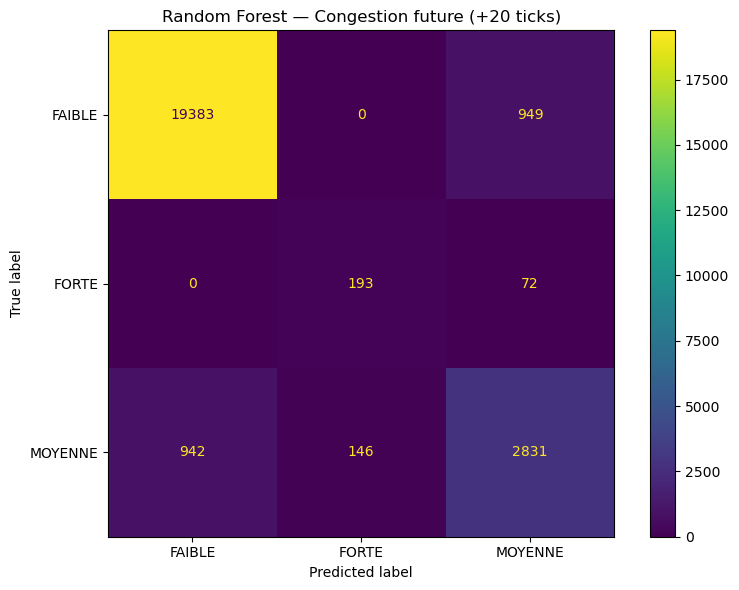

In [13]:
classes = sorted(y.unique())
cm = confusion_matrix(y_test, pred_test, labels=classes)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(ax=ax, values_format="d")
plt.title("Random Forest — Congestion future (+20 ticks)")
plt.tight_layout()
plt.show()

## 14. Importance des variables

,Variable,Importance
2,ticks,0.144917
33,control_mode,0.121998
12,congestion_index_value,0.098756
8,average_speed_value,0.073042
9,avg_wait_current_value,0.042829
18,count_cars_moy5,0.036093
19,stopped_cars_value_delta5,0.032433
16,junction_phase_code_4,0.030239
32,congestion_index_value_moy5,0.028629
13,junction_phase_code_1,0.027500


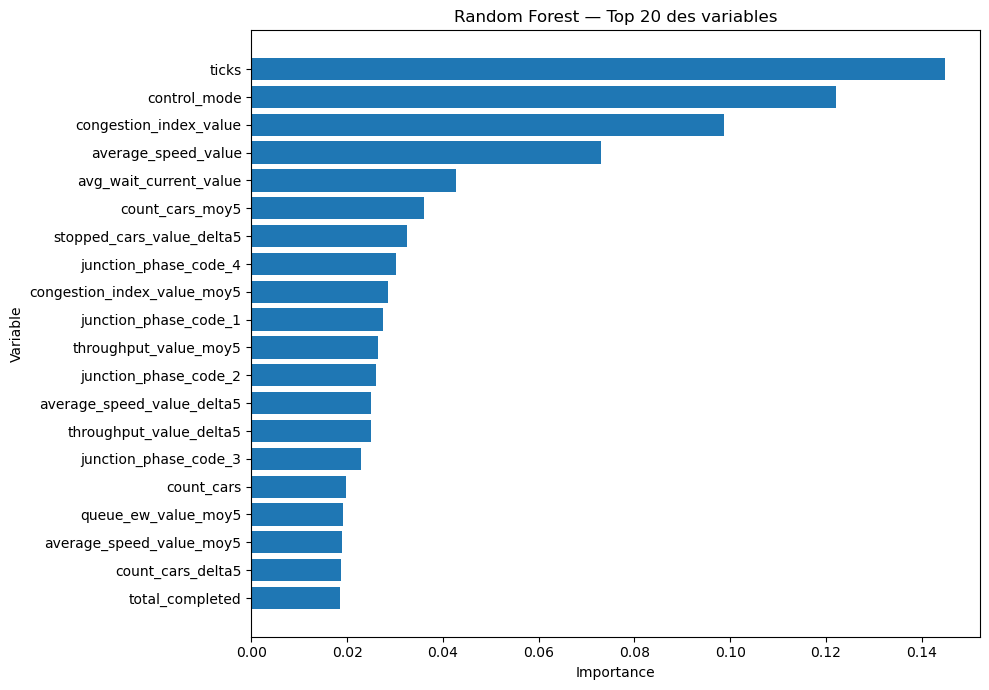

In [14]:
rf_final = best_model.named_steps["rf"]
prep_final = best_model.named_steps["prep"]

# Noms des features après transformation
feature_names = numeric_cols.copy()
if categorical_cols:
    feature_names += categorical_cols

importance = pd.DataFrame({
    "Variable": feature_names,
    "Importance": rf_final.feature_importances_
}).sort_values("Importance", ascending=False)

display(importance.head(25))

top = importance.head(20).sort_values("Importance", ascending=True)

plt.figure(figsize=(10, 7))
plt.barh(top["Variable"], top["Importance"])
plt.xlabel("Importance")
plt.ylabel("Variable")
plt.title("Random Forest — Top 20 des variables")
plt.tight_layout()
plt.show()

## 15. Sauvegarder les résultats

In [15]:
RESULTATS = Path("resultats_random_forest")
RESULTATS.mkdir(exist_ok=True)

essais_df.to_csv(RESULTATS / "comparaison_hyperparametres_validation.csv", index=False)
importance.to_csv(RESULTATS / "importance_variables.csv", index=False)

pred_df = X_test.copy()
pred_df["run"] = g_test.values
pred_df["reel"] = y_test.values
pred_df["prediction"] = pred_test
pred_df.to_csv(RESULTATS / "predictions_test.csv", index=False)

with open(RESULTATS / "rapport_classification.txt", "w", encoding="utf-8") as f:
    f.write(rapport)

metriques = {
    "modele": "RandomForestClassifier",
    "horizon_ticks": HORIZON,
    "meilleure_configuration": best_config,
    "train_rows": int(len(X_train)),
    "validation_rows": int(len(X_val)),
    "test_rows": int(len(X_test)),
    "train_runs": int(g_train.nunique()),
    "validation_runs": int(g_val.nunique()),
    "test_runs": int(g_test.nunique()),
    "test": {
        "accuracy": float(accuracy),
        "balanced_accuracy": float(balanced_acc),
        "f1_macro": float(f1_macro)
    }
}

with open(RESULTATS / "metriques.json", "w", encoding="utf-8") as f:
    json.dump(metriques, f, indent=2, ensure_ascii=False)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
disp.plot(ax=ax, values_format="d")
plt.title("Random Forest — Congestion future (+20 ticks)")
plt.tight_layout()
plt.savefig(RESULTATS / "matrice_confusion.png", dpi=200, bbox_inches="tight")
plt.close()

top = importance.head(20).sort_values("Importance", ascending=True)
plt.figure(figsize=(10, 7))
plt.barh(top["Variable"], top["Importance"])
plt.xlabel("Importance")
plt.ylabel("Variable")
plt.title("Random Forest — Top 20 des variables")
plt.tight_layout()
plt.savefig(RESULTATS / "importance_variables.png", dpi=200, bbox_inches="tight")
plt.close()

print("Résultats enregistrés dans :", RESULTATS.resolve())

Résultats enregistrés dans : C:\Master_1_projets\TP_NETLOGO_GROUPE3_FINAL_CORRIGE\ML_RANDOM_FOREST_GROUPE3\resultats_random_forest


## 16. Comparaison avec CatBoost

Pour une comparaison équitable, compare surtout :
- **F1 Macro**
- **Balanced Accuracy**
- Accuracy globale
- rappel de la classe FORTE
- stabilité sur le jeu test

Le meilleur modèle n'est pas forcément celui qui a la plus grande accuracy brute.